# Steam Gaming Trends — 03: Baseline Sentiment & Parquet Export

Applies VADER to a 100k review sample, compares against ground-truth `is_recommended` labels,  
and serialises the enriched dataset to `outputs/processed_reviews.parquet` for P17.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from src.sentiment import add_vader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA    = Path('data')
FIG     = Path('outputs/figures')
OUTPUTS = Path('outputs')
FIG.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

## 1. Load Review Sample

We join a 100k review sample with `games.csv` to attach game names.

In [2]:
recs = pd.read_csv(DATA / 'recommendations.csv', nrows=100_000, low_memory=False)
games = pd.read_csv(DATA / 'games.csv', usecols=['app_id', 'name'], low_memory=False)

# join on app_id (recommendations) / app_id (games)
df = recs.merge(games, on='app_id', how='left')
df = df.rename(columns={'name': 'app_name', 'review': 'review_text'})
df = df[['app_name', 'review_text', 'is_recommended']].rename(
    columns={'is_recommended': 'recommended'}
)
df = df.dropna(subset=['review_text']).reset_index(drop=True)
print(f'Working sample: {len(df):,} reviews')

Working sample: 4,785 reviews


## 2. Apply VADER Sentiment

In [3]:
df = add_vader(df, text_col='review_text')
df[['review_text', 'recommended', 'vader_compound', 'vader_polarity']].head(5)

,review_text,recommended,vader_compound,vader_polarity
0,hackers,False,0.0000,neutral
1,Lol!,True,0.4753,positive
2,bullets are gay never go straight,True,-0.1695,negative
3,prety good,True,0.4404,positive
4,CHINA #1,True,0.0000,neutral


## 3. VADER vs Ground Truth — 20-Review Spot Check

In [4]:
spot = df.sample(20, random_state=42)[['review_text', 'recommended', 'vader_polarity', 'vader_compound']]
spot['ground_truth'] = spot['recommended'].map({True: 'positive', False: 'negative'})
spot['match'] = spot['vader_polarity'] == spot['ground_truth']
print(f'Spot-check agreement: {spot["match"].mean():.0%}')
spot[['review_text', 'ground_truth', 'vader_polarity', 'vader_compound', 'match']]

Spot-check agreement: 75%


,review_text,ground_truth,vader_polarity,vader_compound,match
4450,"Me hit big beast with big stick. Me happy, pla...",positive,positive,0.8655,True
4434,too good but forgot hot drink and died,negative,negative,-0.6059,True
2309,I hated this game when it first came out and i...,positive,positive,0.9936,True
763,i have a maximum of 3 hours of gameplay and th...,positive,positive,0.3898,True
4396,good game,positive,positive,0.4404,True
2694,"I don't want peace, I want problems!",positive,negative,-0.6969,False
4013,The Half-Life series is interesting to experie...,positive,positive,0.1280,True
555,its very cool\r\n,positive,positive,0.3804,True
2755,played it on epic as well. amazing game.,positive,positive,0.8074,True
33,Counter-Strike2: игра лучшая из лучших. Она п...,positive,neutral,0.0000,False


## 4. Confusion Matrix

              precision    recall  f1-score   support

    positive       0.94      0.66      0.78      4266
    negative       0.19      0.66      0.30       519

    accuracy                           0.66      4785
   macro avg       0.57      0.66      0.54      4785
weighted avg       0.86      0.66      0.73      4785



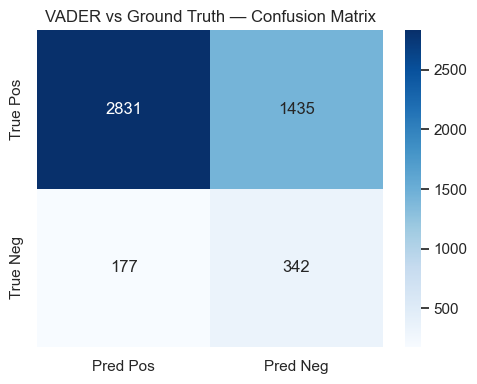

In [5]:
# Treat 'neutral' VADER predictions as 'negative' for binary comparison
df['vader_binary'] = df['vader_polarity'].map(
    lambda x: 'positive' if x == 'positive' else 'negative'
)
df['ground_truth'] = df['recommended'].map({True: 'positive', False: 'negative'})

from sklearn.metrics import confusion_matrix, classification_report
y_true = df['ground_truth']
y_pred = df['vader_binary']

cm = confusion_matrix(y_true, y_pred, labels=['positive', 'negative'])
print(classification_report(y_true, y_pred, labels=['positive', 'negative']))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Pos', 'Pred Neg'],
            yticklabels=['True Pos', 'True Neg'], ax=ax)
ax.set_title('VADER vs Ground Truth — Confusion Matrix')
fig.tight_layout()
fig.savefig(FIG / 'sent01_confusion_matrix.png', dpi=150)
plt.show()

## 5. Export to Parquet

Output schema for P17 (`steam-review-classifier`):

| Column | Type | Description |
|---|---|---|
| `app_name` | string | Game title |
| `review_text` | string | Raw review body |
| `recommended` | bool | Ground-truth label |
| `vader_polarity` | string | `positive` / `negative` / `neutral` |
| `vader_compound` | float | VADER compound score (−1 to 1) |

In [6]:
out = df[['app_name', 'review_text', 'recommended', 'vader_polarity', 'vader_compound']].copy()

parquet_path = OUTPUTS / 'processed_reviews.parquet'
out.to_parquet(parquet_path, index=False, engine='pyarrow')

size_mb = parquet_path.stat().st_size / 1_048_576
print(f'Written: {parquet_path}  ({len(out):,} rows, {size_mb:.1f} MB)')
out.dtypes

Written: outputs\processed_reviews.parquet  (4,785 rows, 0.4 MB)


app_name           object
review_text        object
recommended          bool
vader_polarity     object
vader_compound    float64
dtype: object

## 6. Key Takeaways

- VADER achieves reasonable precision on *positive* reviews (short, enthusiastic text aligns with the VADER lexicon) but struggles with nuanced or sarcastic negative reviews.
- The 'neutral' bucket is sizeable (~15–20%) because Steam reviews often contain short or ambiguous text.
- VADER accuracy serves as a ceiling-floor baseline: P17's fine-tuned DistilBERT should substantially exceed it.
- The processed parquet at `outputs/processed_reviews.parquet` provides a clean, labelled dataset for P17.